# Copper wire production line analysis

## Feature Engineering

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('./Cable-Production-Line-Dataset.csv')

In [3]:
data.keys()

Index(['Machine', 'Shift', 'Operator', 'Date', 'Cable Failures',
       'Cable Failure Downtime', 'Other Failures', 'Other Failure Downtime'],
      dtype='object')

In [4]:
data.head()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime
0,1,A,1,11/6/2020,1,35,1,30
1,2,A,2,11/6/2020,1,10,3,150
2,2,B,3,11/6/2020,2,40,2,110
3,2,A,2,11/7/2020,5,120,1,80
4,2,B,3,11/7/2020,2,40,1,35


In [5]:
data['Shift'].unique()

array(['A', 'B'], dtype=object)

In [6]:
data['Shift'] = data['Shift'].replace({'A': 0, 'B': 1})

C:\Users\Nikit\AppData\Local\Temp\ipykernel_24876\2492628578.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Shift'] = data['Shift'].replace({'A': 0, 'B': 1})


In [7]:
data['Total Failures'] = data['Cable Failures'] + data['Other Failures']
data['Total Downtime'] = data['Cable Failure Downtime'] + data['Other Failure Downtime']

In [8]:
data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(by='Date', inplace=True)

In [9]:
data.to_csv('data.csv')

In [10]:
data.head()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
0,1,0,1,2020-11-06,1,35,1,30,2,65
1,2,0,2,2020-11-06,1,10,3,150,4,160
2,2,1,3,2020-11-06,2,40,2,110,4,150
3,2,0,2,2020-11-07,5,120,1,80,6,200
4,2,1,3,2020-11-07,2,40,1,35,3,75


In [11]:
data.describe()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
count,149.000000,149.000000,149.000000,149,149.000000,149.000000,149.000000,149.00000,149.000000,149.000000
mean,5.932886,0.489933,12.946309,2020-11-15 12:14:29.798657792,1.409396,51.442953,0.536913,47.04698,1.946309,98.489933
min,1.000000,0.000000,1.000000,2020-11-06 00:00:00,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,2.000000,0.000000,6.000000,2020-11-12 00:00:00,0.000000,0.000000,0.000000,0.00000,1.000000,30.000000
50%,5.000000,0.000000,12.000000,2020-11-15 00:00:00,1.000000,35.000000,0.000000,0.00000,1.000000,60.000000
75%,8.000000,1.000000,18.000000,2020-11-19 00:00:00,2.000000,70.000000,1.000000,45.00000,2.000000,120.000000
max,17.000000,1.000000,32.000000,2020-11-22 00:00:00,6.000000,295.000000,9.000000,690.00000,9.000000,690.000000
std,4.294346,0.501585,8.659306,NaN,1.325495,56.658935,0.969281,106.39678,1.417960,112.009750


In [12]:
data['Operator'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  9,  8, 14, 26, 15, 13, 11, 10, 12, 18,
       17, 16, 27, 20, 19, 22, 21, 28, 23, 24, 25, 29, 31, 30, 32])

In [13]:
data['Machine'].unique()

array([ 1,  2,  3,  5,  4,  7, 14,  8, 15,  6,  9, 13, 16, 11, 10, 12, 17])

In [14]:
data['Shift'].unique()

array([0, 1])

<Axes: xlabel='Shift'>

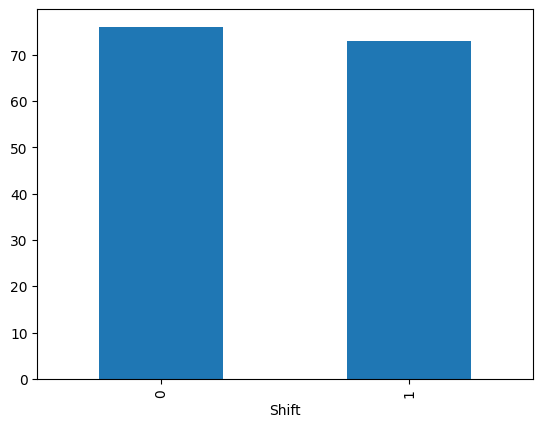

In [15]:
data['Shift'].value_counts().plot.bar()

<Axes: xlabel='Date', ylabel='Failures by date'>

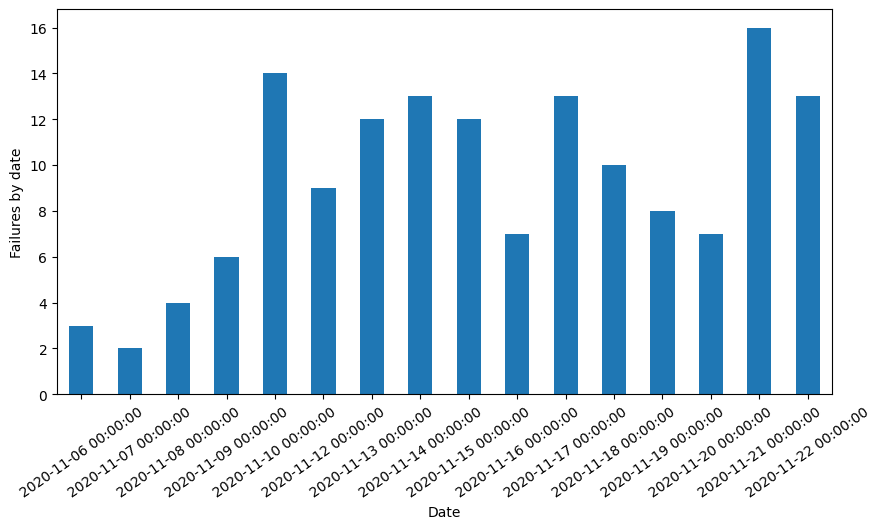

In [16]:
data['Date'].value_counts().sort_index().plot.bar(figsize=(10,5), rot=35, ylabel='Failures by date')

<Axes: xlabel='Date', ylabel='Failures by date'>

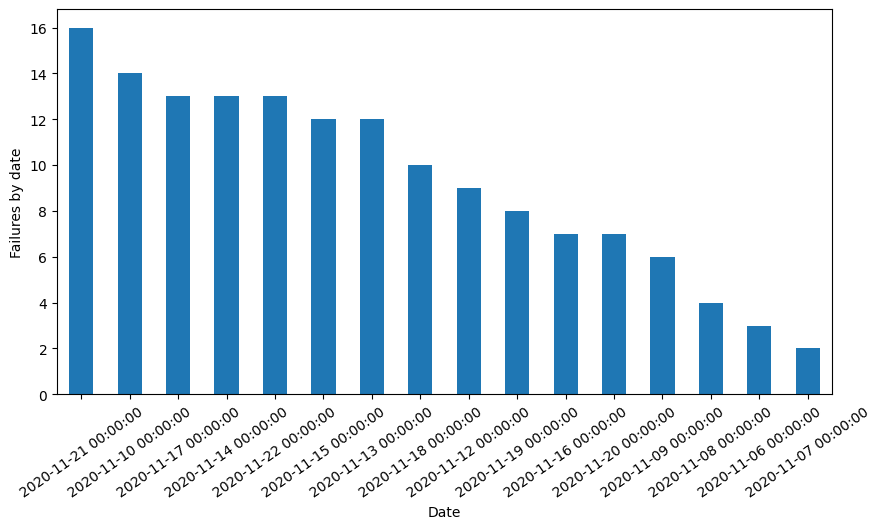

In [17]:
data['Date'].value_counts().plot.bar(figsize=(10,5), rot=35, ylabel='Failures by date')

<Axes: xlabel='Machine', ylabel='Minutes'>

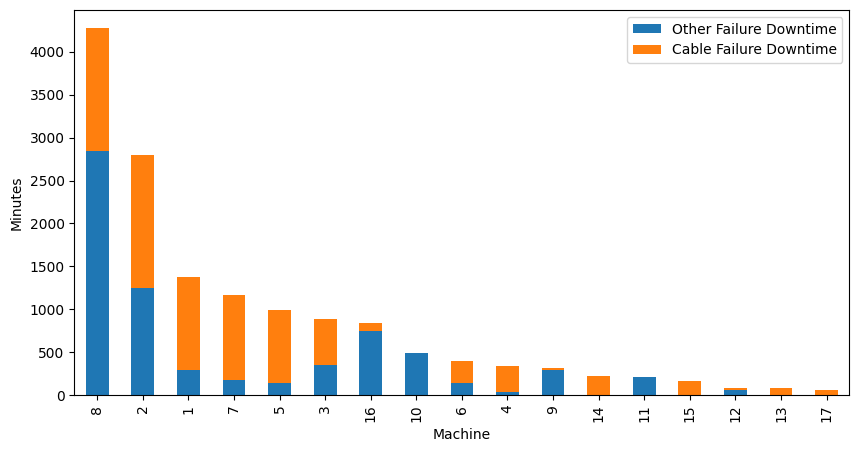

In [18]:
grouped = data.groupby('Machine')[['Other Failure Downtime','Cable Failure Downtime', 'Total Downtime']].sum().sort_values(by='Total Downtime', ascending=False)
grouped.drop(columns='Total Downtime', inplace=True)
grouped.plot.bar(stacked=True, xlabel='Machine', ylabel='Minutes', figsize=(10,5))

<Axes: xlabel='Machine', ylabel='Failure Frequency'>

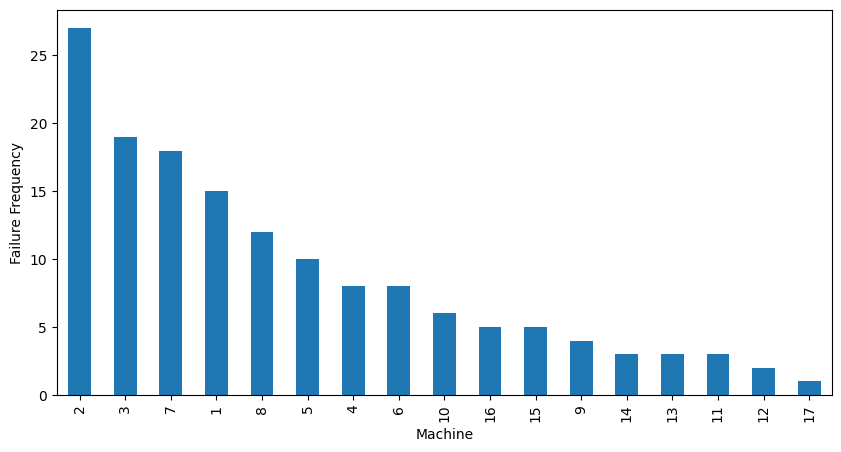

In [19]:
data['Machine'].value_counts().plot.bar(figsize=(10,5), ylabel='Failure Frequency')

<Axes: xlabel='Operator', ylabel='Failure Frequency'>

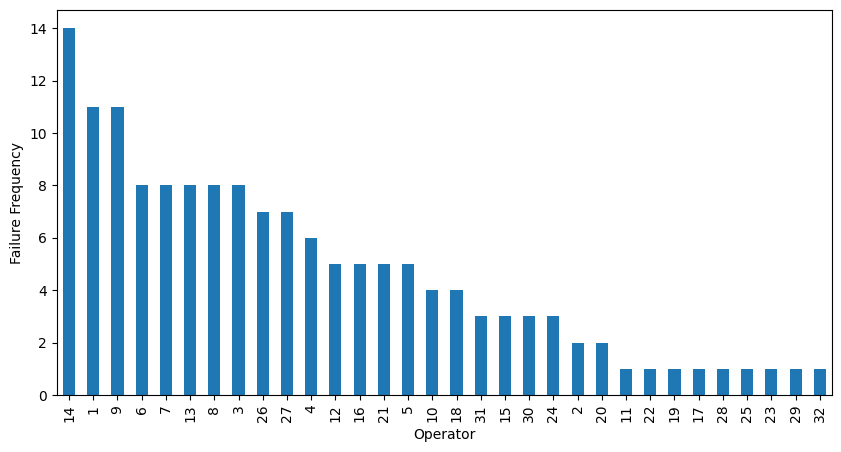

In [20]:
data['Operator'].value_counts().plot.bar(figsize=(10,5), ylabel='Failure Frequency')

In [21]:
data['Cable Failures'].sum()

np.int64(210)

In [22]:
data['Cable Failure Downtime'].sum()

np.int64(7665)

In [23]:
data['Other Failures'].sum()

np.int64(80)

In [24]:
data['Other Failure Downtime'].sum()

np.int64(7010)

In [25]:
corr_matrix = data.corr()

<Axes: >

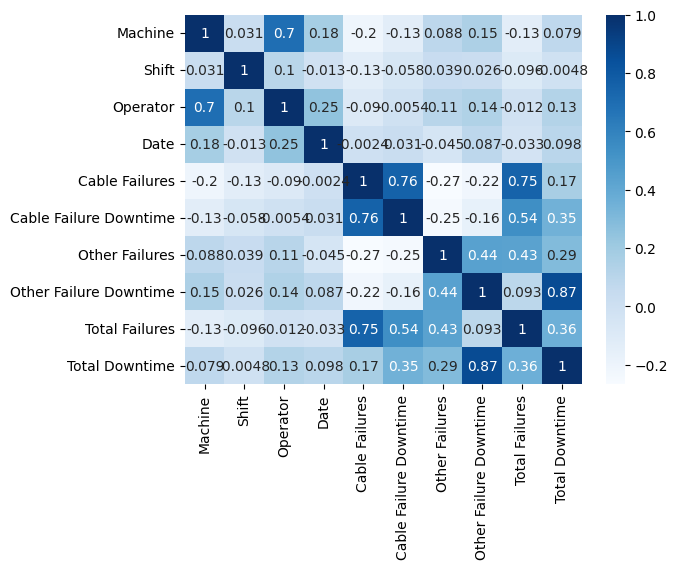

In [26]:
import seaborn as sns
sns.heatmap(corr_matrix, cmap='Blues', annot=True)

## Analysis

In [27]:
grouped = data.groupby(by='Machine')[['Cable Failures', 'Cable Failure Downtime']].sum()
grouped

,Cable Failures,Cable Failure Downtime
Machine,,
1,14,1080
2,65,1555
3,20,540
4,14,305
5,15,855
6,7,260
7,25,980
8,30,1425
9,1,25


<Axes: ylabel='Cable Failure Downtime by Machine'>

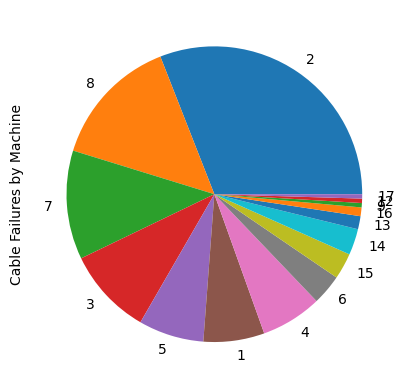

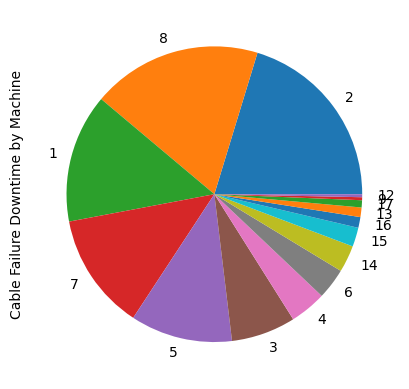

In [28]:
grouped.sort_values(by='Cable Failures', ascending=False).plot.pie(y='Cable Failures', legend=False, label='Cable Failures by Machine')
grouped.sort_values(by='Cable Failure Downtime', ascending=False).plot.pie(y='Cable Failure Downtime', legend=False, label='Cable Failure Downtime by Machine')

In [29]:
grouped = data.groupby(by='Operator')[['Cable Failures', 'Cable Failure Downtime']].sum()
grouped

,Cable Failures,Cable Failure Downtime
Operator,,
1,16,670
2,6,130
3,20,355
4,9,395
5,7,315
6,13,360
7,15,360
8,8,250
9,15,650


<Axes: ylabel='Cable Failure Downtime by Operator'>

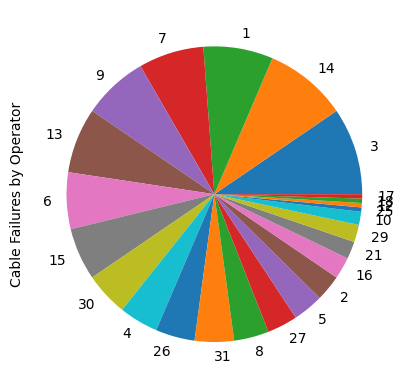

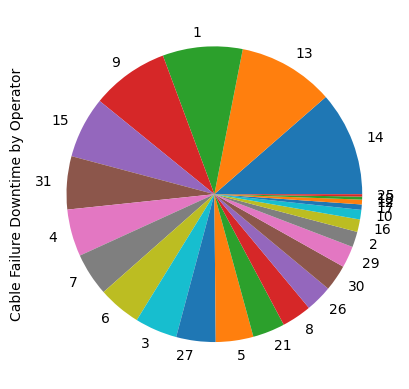

In [30]:
grouped.sort_values(by='Cable Failures', ascending=False).plot.pie(y='Cable Failures', legend=False, label='Cable Failures by Operator')
grouped.sort_values(by='Cable Failure Downtime', ascending=False).plot.pie(y='Cable Failure Downtime', legend=False, label='Cable Failure Downtime by Operator')

In [31]:
grouped = data.groupby(by='Shift')[['Cable Failures', 'Cable Failure Downtime']].sum()
grouped

,Cable Failures,Cable Failure Downtime
Shift,,
0,120,4155
1,90,3510


In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
machine_features = data.groupby('Operator')[['Cable Failures', 'Cable Failure Downtime', 'Other Failures', 'Other Failure Downtime', 
                                            'Total Failures', 'Total Downtime']].sum()

scaled = StandardScaler().fit_transform(machine_features)

kmeans = KMeans(n_clusters=3, random_state=101, n_init=35)
machine_features['Cluster'] = kmeans.fit_predict(scaled)

In [35]:
machine_features.groupby('Cluster').sum()

,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
Cluster,,,,,,
0,16,495,33,1615,49,2110
1,107,3870,28,4125,135,7995
2,87,3300,19,1270,106,4570


In [36]:
machine_features[machine_features['Cluster']==1].index

Index([1, 3, 6, 7, 13, 14, 31], dtype='int64', name='Operator')

In [37]:
machine_features = data.groupby('Machine')[['Cable Failures', 'Cable Failure Downtime', 'Other Failures', 'Other Failure Downtime', 
                                            'Total Failures', 'Total Downtime']].sum()

scaled = StandardScaler().fit_transform(machine_features)

kmeans = KMeans(n_clusters=3, random_state=101, n_init=20)
machine_features['Cluster'] = kmeans.fit_predict(scaled)

In [38]:
machine_features.groupby('Cluster').sum()

,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
Cluster,,,,,,
0,41,1230,32,1965,73,3195
1,95,2980,25,4095,120,7075
2,74,3455,23,950,97,4405


In [39]:
machine_features[machine_features['Cluster']==1].index

Index([2, 8], dtype='int64', name='Machine')

## Нулевая Гипотеза
H0 -- Пропорция брака по сменам одинаковая.   
H1 -- Пропорция брака по сменам не одинаковая. Другими словами, смена влияет на частоту брака.

In [40]:
from scipy.stats import mannwhitneyu

In [41]:
shift0_failures = data[data['Shift']==0]['Cable Failures']
shift1_failures = data[data['Shift']==1]['Cable Failures']

u, p_value = mannwhitneyu(shift0_failures, shift1_failures, alternative='two-sided')
print('P value: ', p_value)

if p_value < 0.05:
    print('Смена влияет на количество брака. Отвергаем H0.')
else:
    print('Смена НЕ влияет на количество брака. Не можем отвергать H0.')

P value:  0.355659591401393
Смена НЕ влияет на количество брака. Не можем отвергать H0.


In [42]:
shift0_failures = data[data['Shift']==0]['Other Failures']
shift1_failures = data[data['Shift']==1]['Other Failures']

u, p_value = mannwhitneyu(shift0_failures, shift1_failures, alternative='two-sided')
print('P value: ', p_value)

if p_value < 0.05:
    print('Смена влияет на количество брака. Отвергаем H0.')
else:
    print('Смена НЕ влияет на количество брака. Не можем отвергать H0.')

P value:  0.9737314963206812
Смена НЕ влияет на количество брака. Не можем отвергать H0.


## Нулевая Гипотеза
H0 -- Пропорция времени простоя по сменам одинаковая.    
H1 -- Пропорция времени простоя по сменам не одинаковая. Другими словами, смена влияет на количество времени простоя.

In [46]:
shift0_failures = data[data['Shift']==0]['Cable Failure Downtime']
shift1_failures = data[data['Shift']==1]['Cable Failure Downtime']

u, p_value = mannwhitneyu(shift0_failures, shift1_failures, alternative='two-sided')
print('P value: ', p_value)

if p_value < 0.05:
    print('Смена влияет на количество брака. Отвергаем H0.')
else:
    print('Смена НЕ влияет на количество брака. Не можем отвергать H0.')

P value:  0.749982079103189
Смена НЕ влияет на количество брака. Не можем отвергать H0.


In [47]:
shift0_failures = data[data['Shift']==0]['Other Failure Downtime']
shift1_failures = data[data['Shift']==1]['Other Failure Downtime']

u, p_value = mannwhitneyu(shift0_failures, shift1_failures, alternative='two-sided')
print('P value: ', p_value)

if p_value < 0.05:
    print('Смена влияет на количество брака. Отвергаем H0.')
else:
    print('Смена НЕ влияет на количество брака. Не можем отвергать H0.')

P value:  0.9434185746695916
Смена НЕ влияет на количество брака. Не можем отвергать H0.


## Итоги
Более 50% брака произошло на машинах 2, 8, 7.    
50% простоя произошло на машинах 2, 8, 1.    
Самые рисковые машины: 2, 8.

50% брака случилось у операторов 3, 14, 1, 7, 9, 13, 6.    
50% простоя произошло у операторов 14, 13, 1, 9, 15, 31.   
Самые рисковые операторы: 1, 3, 6, 7, 13, 14, 31.

На 33% больше поломок произошло при смене A.   
На 18% больше простоя произошло при смене A.
Смены не влияют на количество времени простоя.

## Рекомендации
Посмотреть работали ли операторы 1, 3, 6, 7, 13, 14, 15, 31 в основном на машиинах 1, 2, 8, 7.